In [59]:
import urllib.request
import pandas
from sklearn.preprocessing import LabelEncoder
import seaborn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

In [60]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x2645548f7d0>)

In [61]:
df_stars = pandas.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [62]:
le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars["Star type"] = le.fit_transform(df_stars["Star type"])
labels = le.inverse_transform(df_stars["Star type"])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


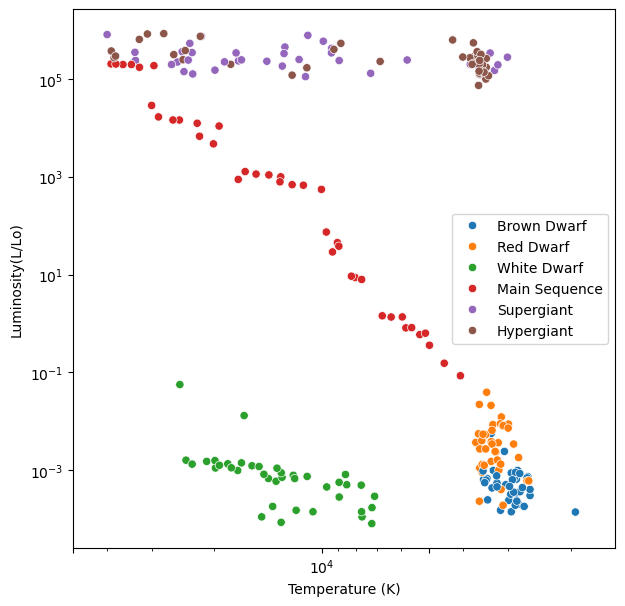

In [63]:
fig = plt.figure(figsize=(7, 7))
seaborn.scatterplot(data=df_stars, x="Temperature (K)", y="Luminosity(L/Lo)", hue=labels)
plt.xscale("log")
plt.yscale("log")
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [64]:
#len of X is length of df_stars, len of X[i] is columns
X = np.array([df_stars["Temperature (K)"], df_stars["Luminosity(L/Lo)"], df_stars["Radius(R/Ro)"], df_stars["Absolute magnitude(Mv)"]])

np.random.seed(8)
n_components = 3

# use Randomized PCA for speed
# pca = RandomizedPCA(n_components - 1)
pca = PCA(n_components - 1, svd_solver="randomized")
pca.fit(X)
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Expained fractional variance of data encapsulated in the eigenvalues: [0.99726852 0.00272838]


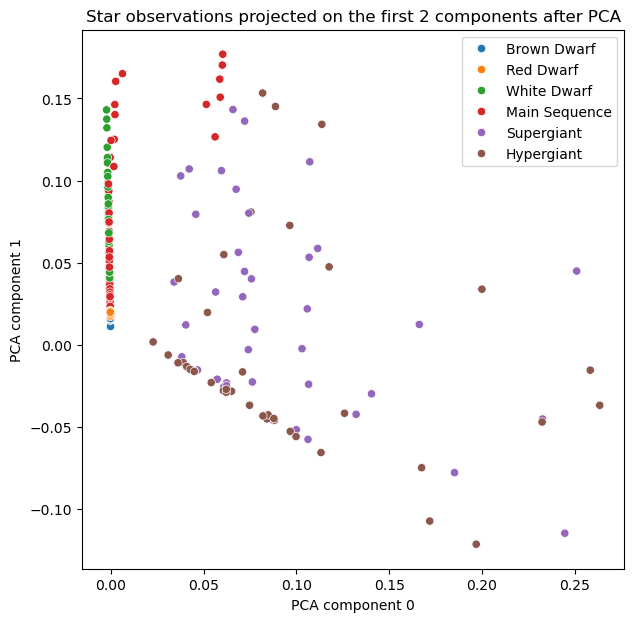

In [65]:
fig = plt.figure(figsize=(7, 7))
seaborn.scatterplot(x=pca.components_[:][0], y=pca.components_[:][1], hue=labels)
plt.title("Star observations projected on the first 2 components after PCA")
plt.xlabel("PCA component 0")
plt.ylabel("PCA component 1")
plt.show()

In [66]:
#NORMALISING
#subtracting the mean
df_stars["Temperature (K)"]-np.mean(df_stars["Temperature (K)"])


Y = np.array([(df_stars["Temperature (K)"]-np.mean(df_stars["Temperature (K)"]))/np.std(df_stars["Temperature (K)"]), (df_stars["Luminosity(L/Lo)"]-np.mean(df_stars["Luminosity(L/Lo)"]))/np.std(df_stars["Luminosity(L/Lo)"]), (df_stars["Radius(R/Ro)"]-np.mean(df_stars["Radius(R/Ro)"]))/np.std(df_stars["Radius(R/Ro)"]), (df_stars["Absolute magnitude(Mv)"]-np.mean(df_stars["Absolute magnitude(Mv)"]))/np.std(df_stars["Absolute magnitude(Mv)"])])

np.random.seed(8)
n_components = 3

# use Randomized PCA for speed
# pca = RandomizedPCA(n_components - 1)
pca = PCA(n_components - 1, svd_solver="randomized")
pca.fit(Y)
evals = pca.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

Expained fractional variance of data encapsulated in the eigenvalues: [0.6157261  0.27356924]


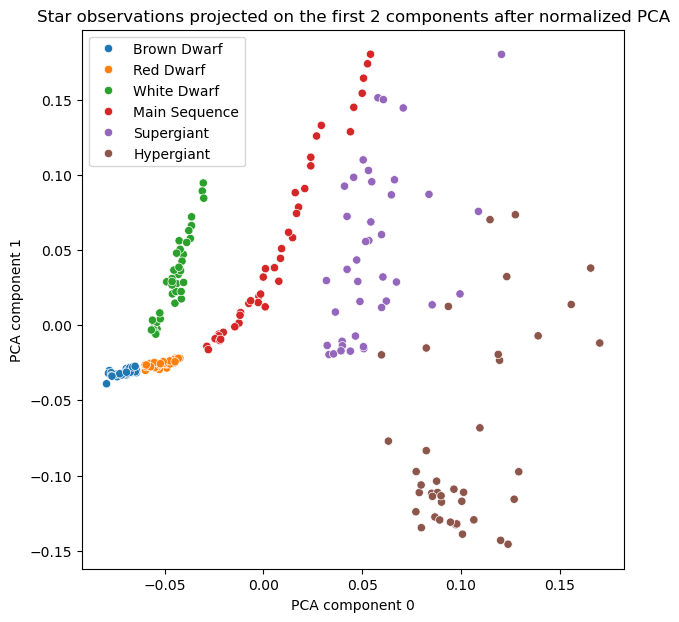

In [67]:
fig = plt.figure(figsize=(7, 7))
seaborn.scatterplot(x=pca.components_[:][0], y=pca.components_[:][1], hue=labels)
plt.title("Star observations projected on the first 2 components after normalized PCA")
plt.xlabel("PCA component 0")
plt.ylabel("PCA component 1")
plt.show()